In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier

In [3]:
df = pd.read_csv("lungcancer.csv")
df

,nct_id,title,status,start_date,phase,study_type,conditions,sex,min_age,max_age,...,has_washout_period,excludes_cns_involvement,excludes_other_malignancy,has_contraception_requirement,endpoint_type,endpoint_confidence,endpoint_keyword_matches,trial_complexity_score,trial_complexity_band,complexity_breakdown
0,NCT06841874,Expanded Access Program of Taletrectinib in Pa...,NO_LONGER_AVAILABLE,NaN,NaN,EXPANDED_ACCESS,Lung Neoplasms; Respiratory Tract Neoplasms; T...,ALL,18.0,NaN,...,True,False,False,False,Other,Low,{},26,Low,"{""age_constraints"": 0, ""complexity_band"": ""Low..."
1,NCT01386203,Exhaled Breath Biomarkers in Lung Cancer,UNKNOWN,2011-06,NaN,OBSERVATIONAL,Lung Cancer,ALL,18.0,95.0,...,False,False,False,False,Other,Low,{},4,Low,"{""age_constraints"": 0, ""complexity_band"": ""Low..."
2,NCT04606446,Study of PF-07248144 in Advanced or Metastatic...,RECRUITING,2020-11-16,PHASE2,INTERVENTIONAL,Locally Advanced or Metastatic ER+ HER2- Breas...,ALL,18.0,NaN,...,False,False,True,True,Dose Finding,Medium,"{""Dose Finding"": [""dose limiting toxicity"", ""d...",68,High,"{""age_constraints"": 0, ""complexity_band"": ""Hig..."
3,NCT04852588,Chest Lymph Node Sampling in Patients With Adv...,RECRUITING,2021-11-09,NaN,INTERVENTIONAL,Non-Small Cell Lung Cancer,ALL,18.0,NaN,...,False,False,False,False,Other,Low,{},23,Low,"{""age_constraints"": 0, ""complexity_band"": ""Low..."
4,NCT07274761,Neoadjuvant Sunvozertinib in Stage II-IIIB Non...,ACTIVE_NOT_RECRUITING,2024-10-17,PHASE2,INTERVENTIONAL,Potentially Resectable EGFR Exon 20 Insertion ...,ALL,18.0,NaN,...,False,False,False,True,Response Rate,High,"{""Response Rate"": [""objective response rate"", ...",47,Medium,"{""age_constraints"": 0, ""complexity_band"": ""Med..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,NCT00072527,Cisplatin and Irinotecan Followed by Carboplat...,COMPLETED,2003-11,PHASE2,INTERVENTIONAL,Lung Cancer,ALL,18.0,NaN,...,False,False,False,False,Other,Low,{},50,Medium,"{""age_constraints"": 0, ""complexity_band"": ""Med..."
96,NCT06835569,A Study to Learn About Study Medicine ALTA3263...,RECRUITING,2025-03-05,PHASE1,INTERVENTIONAL,Cancer; PDAC - Pancreatic Ductal Adenocarcinom...,ALL,18.0,NaN,...,False,False,False,False,Dose Finding,Medium,"{""Dose Finding"": [""dose limiting toxicity""], ""...",60,Medium,"{""age_constraints"": 0, ""complexity_band"": ""Med..."
97,NCT06618391,Local Injection and Systemic Therapy in the Tr...,NOT_YET_RECRUITING,2024-10-08,PHASE2,INTERVENTIONAL,Non-small Cell Lung Cancer,ALL,18.0,NaN,...,True,True,False,True,Other,Low,{},58,Medium,"{""age_constraints"": 0, ""complexity_band"": ""Med..."
98,NCT03568097,Immunotherapy in Combination With Chemotherapy...,UNKNOWN,2018-09-16,PHASE2,INTERVENTIONAL,Small Cell Lung Carcinoma,ALL,18.0,NaN,...,True,True,False,False,Survival,High,"{""Survival"": [""progression-free survival"", ""pf...",75,High,"{""age_constraints"": 0, ""complexity_band"": ""Hig..."


In [5]:
df.head()

,nct_id,title,status,start_date,phase,study_type,conditions,sex,min_age,max_age,...,has_washout_period,excludes_cns_involvement,excludes_other_malignancy,has_contraception_requirement,endpoint_type,endpoint_confidence,endpoint_keyword_matches,trial_complexity_score,trial_complexity_band,complexity_breakdown
0,NCT06841874,Expanded Access Program of Taletrectinib in Pa...,NO_LONGER_AVAILABLE,NaN,NaN,EXPANDED_ACCESS,Lung Neoplasms; Respiratory Tract Neoplasms; T...,ALL,18.0,NaN,...,True,False,False,False,Other,Low,{},26,Low,"{""age_constraints"": 0, ""complexity_band"": ""Low..."
1,NCT01386203,Exhaled Breath Biomarkers in Lung Cancer,UNKNOWN,2011-06,NaN,OBSERVATIONAL,Lung Cancer,ALL,18.0,95.0,...,False,False,False,False,Other,Low,{},4,Low,"{""age_constraints"": 0, ""complexity_band"": ""Low..."
2,NCT04606446,Study of PF-07248144 in Advanced or Metastatic...,RECRUITING,2020-11-16,PHASE2,INTERVENTIONAL,Locally Advanced or Metastatic ER+ HER2- Breas...,ALL,18.0,NaN,...,False,False,True,True,Dose Finding,Medium,"{""Dose Finding"": [""dose limiting toxicity"", ""d...",68,High,"{""age_constraints"": 0, ""complexity_band"": ""Hig..."
3,NCT04852588,Chest Lymph Node Sampling in Patients With Adv...,RECRUITING,2021-11-09,NaN,INTERVENTIONAL,Non-Small Cell Lung Cancer,ALL,18.0,NaN,...,False,False,False,False,Other,Low,{},23,Low,"{""age_constraints"": 0, ""complexity_band"": ""Low..."
4,NCT07274761,Neoadjuvant Sunvozertinib in Stage II-IIIB Non...,ACTIVE_NOT_RECRUITING,2024-10-17,PHASE2,INTERVENTIONAL,Potentially Resectable EGFR Exon 20 Insertion ...,ALL,18.0,NaN,...,False,False,False,True,Response Rate,High,"{""Response Rate"": [""objective response rate"", ...",47,Medium,"{""age_constraints"": 0, ""complexity_band"": ""Med..."


In [6]:
df.tail()

,nct_id,title,status,start_date,phase,study_type,conditions,sex,min_age,max_age,...,has_washout_period,excludes_cns_involvement,excludes_other_malignancy,has_contraception_requirement,endpoint_type,endpoint_confidence,endpoint_keyword_matches,trial_complexity_score,trial_complexity_band,complexity_breakdown
95,NCT00072527,Cisplatin and Irinotecan Followed by Carboplat...,COMPLETED,2003-11,PHASE2,INTERVENTIONAL,Lung Cancer,ALL,18.0,NaN,...,False,False,False,False,Other,Low,{},50,Medium,"{""age_constraints"": 0, ""complexity_band"": ""Med..."
96,NCT06835569,A Study to Learn About Study Medicine ALTA3263...,RECRUITING,2025-03-05,PHASE1,INTERVENTIONAL,Cancer; PDAC - Pancreatic Ductal Adenocarcinom...,ALL,18.0,NaN,...,False,False,False,False,Dose Finding,Medium,"{""Dose Finding"": [""dose limiting toxicity""], ""...",60,Medium,"{""age_constraints"": 0, ""complexity_band"": ""Med..."
97,NCT06618391,Local Injection and Systemic Therapy in the Tr...,NOT_YET_RECRUITING,2024-10-08,PHASE2,INTERVENTIONAL,Non-small Cell Lung Cancer,ALL,18.0,NaN,...,True,True,False,True,Other,Low,{},58,Medium,"{""age_constraints"": 0, ""complexity_band"": ""Med..."
98,NCT03568097,Immunotherapy in Combination With Chemotherapy...,UNKNOWN,2018-09-16,PHASE2,INTERVENTIONAL,Small Cell Lung Carcinoma,ALL,18.0,NaN,...,True,True,False,False,Survival,High,"{""Survival"": [""progression-free survival"", ""pf...",75,High,"{""age_constraints"": 0, ""complexity_band"": ""Hig..."
99,NCT00048997,Radiation Therapy in Preventing Central Nervou...,COMPLETED,2002-09,PHASE3,INTERVENTIONAL,Lung Cancer,ALL,18.0,NaN,...,False,False,True,True,Survival,High,"{""Survival"": [""overall survival""]}",51,Medium,"{""age_constraints"": 0, ""complexity_band"": ""Med..."


In [7]:
df.shape

(100, 37)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 37 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   nct_id                         100 non-null    object 
 1   title                          100 non-null    object 
 2   status                         100 non-null    object 
 3   start_date                     97 non-null     object 
 4   phase                          60 non-null     object 
 5   study_type                     100 non-null    object 
 6   conditions                     100 non-null    object 
 7   sex                            100 non-null    object 
 8   min_age                        97 non-null     float64
 9   max_age                        23 non-null     float64
 10  interventions                  92 non-null     object 
 11  sponsor                        100 non-null    object 
 12  sponsor_class                  100 non-null    obje

In [9]:
df.describe()

,min_age,max_age,trial_complexity_score
count,97.000000,23.000000,100.00000
mean,19.257732,81.782609,43.68000
std,8.063909,21.349806,30.98774
min,0.000000,21.000000,0.00000
25%,18.000000,72.000000,14.25000
50%,18.000000,80.000000,43.50000
75%,18.000000,97.000000,67.00000
max,70.000000,120.000000,100.00000


In [10]:
df.isnull().sum()

nct_id                            0
title                             0
status                            0
start_date                        3
phase                            40
study_type                        0
conditions                        0
sex                               0
min_age                           3
max_age                          77
interventions                     8
sponsor                           0
sponsor_class                     0
eligibility_raw                   0
primary_outcomes                  5
secondary_outcomes               23
is_relapsed_refractory            0
requires_prior_therapy            0
requires_measurable_disease       0
has_ecog_requirement              0
has_lab_thresholds                0
excludes_infection                0
excludes_hiv_hepatitis            0
excludes_pregnancy                0
excludes_prior_car_t_or_bcma      0
has_biomarker_requirement         0
has_transplant_requirement        0
has_washout_period          

In [11]:
categorical_columns = [
    'phase',
    'interventions',
    'primary_outcomes',
    'secondary_outcomes'
]

for col in categorical_columns:
    df[col] = df[col].fillna('Unknown')

In [12]:
df['min_age'] = df['min_age'].fillna(df['min_age'].median())

df['max_age'] = df['max_age'].fillna(df['max_age'].median())

In [13]:
df['start_date'] = df['start_date'].fillna('Unknown')

In [14]:
df['secondary_outcomes'] = df['secondary_outcomes'].fillna('Unknown')

In [15]:
print(df.isnull().sum())

nct_id                           0
title                            0
status                           0
start_date                       0
phase                            0
study_type                       0
conditions                       0
sex                              0
min_age                          0
max_age                          0
interventions                    0
sponsor                          0
sponsor_class                    0
eligibility_raw                  0
primary_outcomes                 0
secondary_outcomes               0
is_relapsed_refractory           0
requires_prior_therapy           0
requires_measurable_disease      0
has_ecog_requirement             0
has_lab_thresholds               0
excludes_infection               0
excludes_hiv_hepatitis           0
excludes_pregnancy               0
excludes_prior_car_t_or_bcma     0
has_biomarker_requirement        0
has_transplant_requirement       0
has_washout_period               0
excludes_cns_involve

In [16]:
print("Total Missing Values:",
      df.isnull().sum().sum())

Total Missing Values: 0


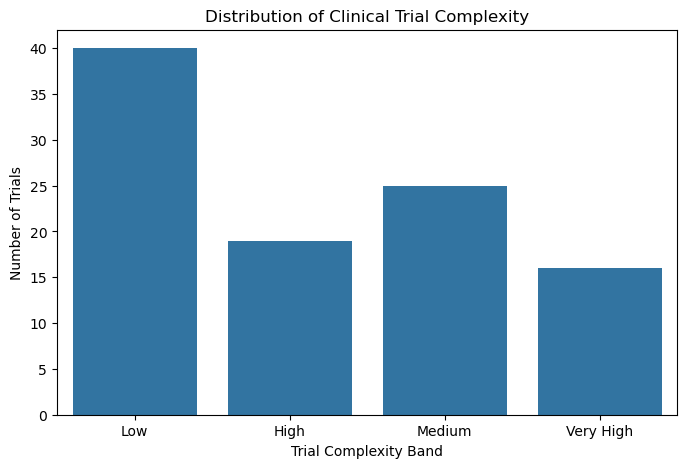

In [17]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='trial_complexity_band'
)

plt.title("Distribution of Clinical Trial Complexity")
plt.xlabel("Trial Complexity Band")
plt.ylabel("Number of Trials")

plt.show()

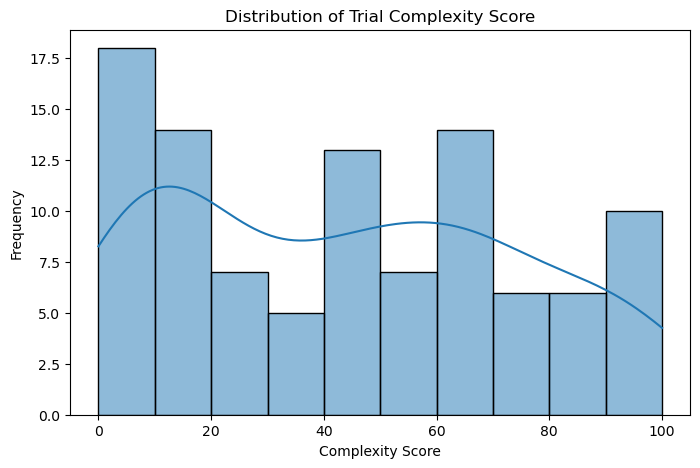

In [18]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df['trial_complexity_score'],
    bins=10,
    kde=True
)

plt.title("Distribution of Trial Complexity Score")
plt.xlabel("Complexity Score")
plt.ylabel("Frequency")

plt.show()

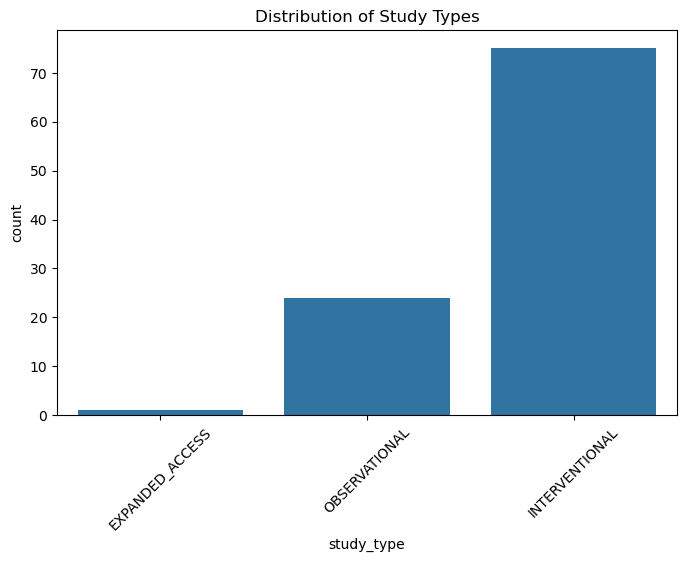

In [19]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='study_type'
)

plt.title("Distribution of Study Types")
plt.xticks(rotation=45)

plt.show()

In [20]:
features = [
    'min_age',
    'max_age',
    'is_relapsed_refractory',
    'requires_prior_therapy',
    'requires_measurable_disease',
    'has_ecog_requirement',
    'has_lab_thresholds',
    'excludes_infection',
    'excludes_hiv_hepatitis',
    'excludes_pregnancy',
    'excludes_prior_car_t_or_bcma',
    'has_biomarker_requirement',
    'has_transplant_requirement',
    'has_washout_period',
    'excludes_cns_involvement',
    'excludes_other_malignancy',
    'has_contraception_requirement'
]

In [21]:
X = df[features]

y = df['trial_complexity_band']

In [22]:
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

In [23]:
print(label_encoder.classes_)

['High' 'Low' 'Medium' 'Very High']


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [25]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [26]:
y_pred = model.predict(X_test)

In [27]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Accuracy: 0.85
Accuracy Percentage: 85.0 %


In [28]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

        High       0.75      0.75      0.75         4
         Low       0.89      1.00      0.94         8
      Medium       0.80      0.80      0.80         5
   Very High       1.00      0.67      0.80         3

    accuracy                           0.85        20
   macro avg       0.86      0.80      0.82        20
weighted avg       0.86      0.85      0.85        20



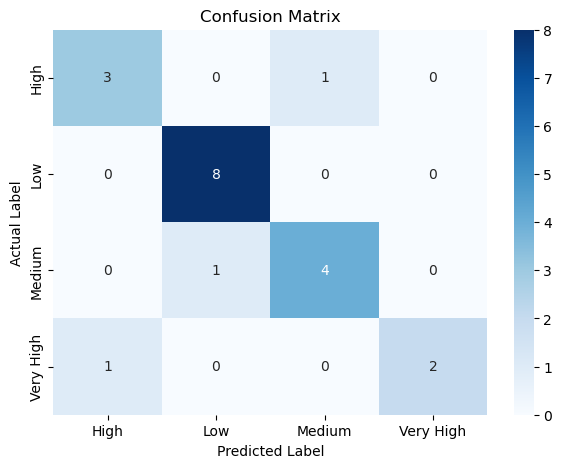

In [29]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()